In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

In [36]:
df = pd.read_csv('Sunspots.csv', parse_dates=['Date'])
df

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7
...,...,...,...
3260,3260,2020-09-30,0.6
3261,3261,2020-10-31,14.4
3262,3262,2020-11-30,34.0
3263,3263,2020-12-31,21.8


In [37]:
df.rename(
    columns={
        'Monthly Mean Total Sunspot Number': 'Number'
    },
    inplace=True
)

In [38]:
df

,Unnamed: 0,Date,Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7
...,...,...,...
3260,3260,2020-09-30,0.6
3261,3261,2020-10-31,14.4
3262,3262,2020-11-30,34.0
3263,3263,2020-12-31,21.8


In [39]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
#import statmodels.api as sm

<Axes: xlabel='Date', ylabel='Number'>

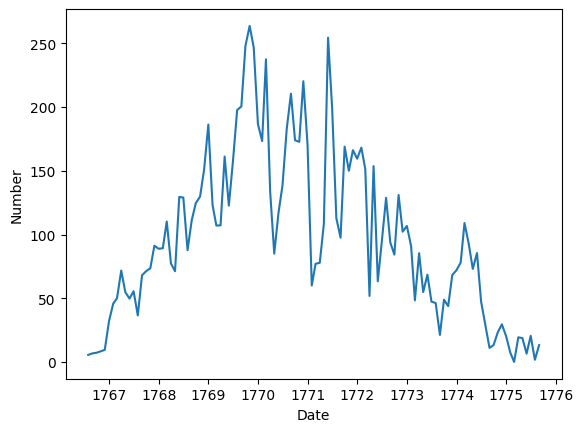

In [41]:
sns.lineplot(df.iloc[210:320], x='Date', y='Number')

In [42]:
rise = df.iloc[210:260]

<Axes: xlabel='Date', ylabel='Number'>

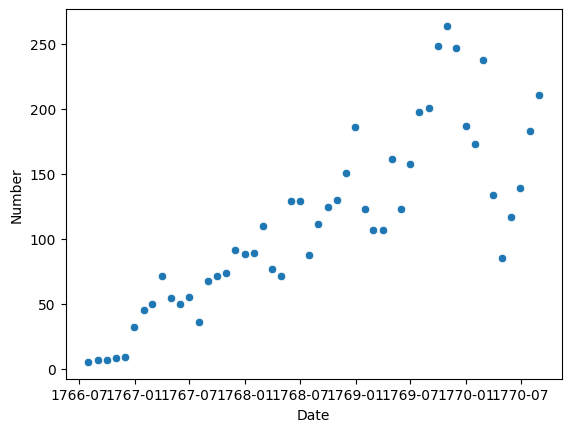

In [43]:
sns.scatterplot(df.iloc[210:260], x='Date', y='Number')

In [44]:
rise

,Unnamed: 0,Date,Number
210,210,1766-07-31,5.5
211,211,1766-08-31,6.7
212,212,1766-09-30,7.2
213,213,1766-10-31,8.3
214,214,1766-11-30,9.5
215,215,1766-12-31,32.0
216,216,1767-01-31,45.7
217,217,1767-02-28,50.0
218,218,1767-03-31,71.7
219,219,1767-04-30,54.8


In [45]:
ts = rise.Date.iloc[0]
ts

Timestamp('1766-07-31 00:00:00')

In [46]:
import datetime

In [47]:
ts.strftime("%Y%m")

'176607'

In [48]:
rise['ym'] = rise.Date.apply(lambda dt: int(dt.strftime("%Y%m")))

In [49]:
rise.ym.diff()

210     NaN
211     1.0
212     1.0
213     1.0
214     1.0
215     1.0
216    89.0
217     1.0
218     1.0
219     1.0
220     1.0
221     1.0
222     1.0
223     1.0
224     1.0
225     1.0
226     1.0
227     1.0
228    89.0
229     1.0
230     1.0
231     1.0
232     1.0
233     1.0
234     1.0
235     1.0
236     1.0
237     1.0
238     1.0
239     1.0
240    89.0
241     1.0
242     1.0
243     1.0
244     1.0
245     1.0
246     1.0
247     1.0
248     1.0
249     1.0
250     1.0
251     1.0
252    89.0
253     1.0
254     1.0
255     1.0
256     1.0
257     1.0
258     1.0
259     1.0
Name: ym, dtype: float64

In [50]:
nf = pd.DataFrame()

In [51]:
nf['spots'] = rise.Number

In [52]:
nf['n_month'] = rise.index

In [53]:
nf

,spots,n_month
210,5.5,210
211,6.7,211
212,7.2,212
213,8.3,213
214,9.5,214
215,32.0,215
216,45.7,216
217,50.0,217
218,71.7,218
219,54.8,219


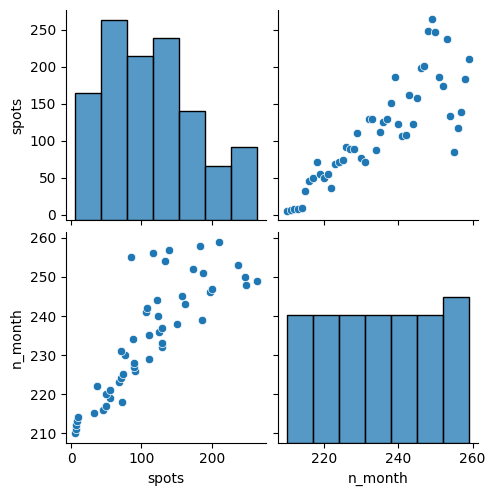

In [54]:
sns.pairplot(nf)

In [55]:
nf.corr()

,spots,n_month
spots,1.000000,0.841703
n_month,0.841703,1.000000


In [57]:
import matplotlib.pyplot as plt

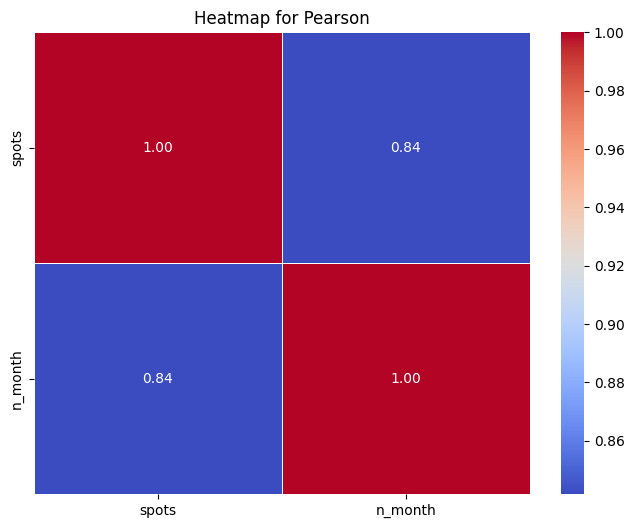

In [58]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    nf.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Heatmap for Pearson')
plt.show()

In [59]:
nf.corr()**2

,spots,n_month
spots,1.000000,0.708463
n_month,0.708463,1.000000


<Axes: xlabel='spots', ylabel='n_month'>

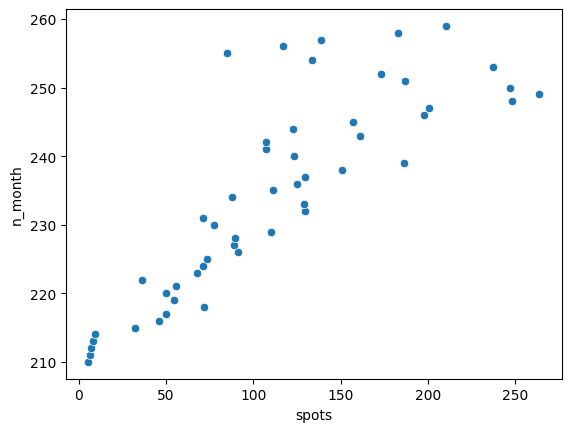

In [67]:
sns.scatterplot(
    data = nf[['spots', 'n_month']], 
    x='spots',
    y='n_month',
)

In [65]:
pip install statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.5 MB 9.4 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.5 MB 11.3 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.5 MB 11.4 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 11.0 MB/s eta 0:00:00
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import statsmodels.api as sm

In [70]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
from sklearn import linear_model